# Aspect-Based Sentiment Analysis (ABSA)
**CDS6344 Social Media Computing — Amazon Reviews Sentiment Analysis**

This notebook implements:
1. **Opinion Mining** — Extract opinion targets using dependency parsing (spaCy)
2. **ABSA** — Identify sentiments towards specific product aspects:
   - Delivery / Shipping
   - Product Quality
   - Price / Value
   - Customer Service
   - Packaging
3. **Aspect-wise sentiment visualization**

## 1. Install & Import

In [ ]:
!pip install spacy transformers torch pandas numpy matplotlib seaborn plotly wordcloud -q
!python -m spacy download en_core_web_sm -q

[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [ ]:
import pandas as pd
import numpy as np
import re
import spacy
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
from collections import defaultdict, Counter

import torch
from transformers import pipeline

nlp = spacy.load('en_core_web_sm')
print('spaCy loaded:', nlp.meta['name'])

spaCy loaded: core_web_sm


## 2. Load & Prepare Dataset

In [ ]:
df = pd.read_csv('Amazon_Reviews.csv', on_bad_lines='skip', engine='python')

def rating_to_sentiment(r):
    if pd.isna(r): return None
    m = re.search(r'(\d)', str(r))
    if not m: return None
    s = int(m.group(1))
    return 'Negative' if s <= 2 else ('Neutral' if s == 3 else 'Positive')

df['Sentiment'] = df['Rating'].apply(rating_to_sentiment)
df = df.dropna(subset=['Sentiment', 'Review Text'])
df = df[df['Review Text'].str.strip() != ''].reset_index(drop=True)

# Use a sample for ABSA (spaCy is CPU-bound)
df_absa = df.sample(n=min(3000, len(df)), random_state=42).reset_index(drop=True)
print(f'ABSA sample size: {len(df_absa)}')

ABSA sample size: 3000


## 3. Aspect Keyword Dictionary

In [ ]:
# Aspect keyword groups — maps surface forms to canonical aspect names
ASPECT_KEYWORDS = {
    'Delivery': [
        'delivery', 'shipping', 'arrived', 'arrive', 'dispatch',
        'shipped', 'transit', 'courier', 'late', 'on time', 'fast delivery',
        'slow delivery', 'package', 'days'
    ],
    'Product Quality': [
        'quality', 'durable', 'durability', 'broken', 'defective',
        'damaged', 'excellent', 'poor quality', 'cheap', 'sturdy',
        'well made', 'flimsy', 'build', 'material', 'finish'
    ],
    'Price / Value': [
        'price', 'cost', 'expensive', 'cheap', 'value', 'worth',
        'overpriced', 'affordable', 'money', 'refund', 'discount', 'fee'
    ],
    'Customer Service': [
        'service', 'support', 'customer service', 'staff', 'response',
        'helpful', 'rude', 'contact', 'reply', 'resolved', 'complaint',
        'help', 'representative', 'agent'
    ],
    'Packaging': [
        'packaging', 'package', 'box', 'wrapped', 'wrapping',
        'unpacked', 'sealed', 'plastic', 'bag', 'container'
    ]
}

def detect_aspects(text):
    """Return list of aspects mentioned in the text."""
    text_lower = text.lower()
    found = []
    for aspect, keywords in ASPECT_KEYWORDS.items():
        if any(kw in text_lower for kw in keywords):
            found.append(aspect)
    return found if found else ['General']

df_absa['Aspects'] = df_absa['Review Text'].apply(detect_aspects)
print('Aspects detected. Sample:')
print(df_absa[['Review Text', 'Sentiment', 'Aspects']].head(5))

Aspects detected. Sample:
                                         Review Text Sentiment  \
0  Disgusting! I ordered an expensive item with a...  Negative   
1  Charging me for items I sent back on numerous ...  Negative   
2  I bought a s*** product on Amazon (came broken...  Negative   
3  Pathetic customer service. For a well known br...  Negative   
4  They need to stop the 2 types of bait and swit...  Negative   

                                             Aspects  
0  [Delivery, Product Quality, Price / Value, Cus...  
1       [Price / Value, Customer Service, Packaging]  
2                                  [Product Quality]  
3                                 [Customer Service]  
4         [Delivery, Product Quality, Price / Value]  


## 4. Opinion Mining via Dependency Parsing (spaCy)

In [ ]:
def extract_opinion_targets(text, max_chars=500):
    """
    Use spaCy dependency parsing to extract (aspect noun, opinion adjective) pairs.
    Looks for adjective modifiers (amod) attached to nouns.
    """
    text = str(text)[:max_chars]
    doc  = nlp(text)
    pairs = []
    for token in doc:
        if token.dep_ == 'amod' and token.head.pos_ in ('NOUN', 'PROPN'):
            pairs.append((token.head.text.lower(), token.text.lower()))
    return pairs

print('Running opinion mining on sample reviews...')
# Run on a small sample (300) to keep it fast
sample = df_absa.sample(n=300, random_state=42)
all_pairs = []
for text in sample['Review Text']:
    all_pairs.extend(extract_opinion_targets(text))

# Most common opinion targets
target_counts = Counter([p[0] for p in all_pairs])
opinion_counts = Counter([p[1] for p in all_pairs])

print('\nTop 15 Opinion Targets (nouns):')
for t, c in target_counts.most_common(15):
    print(f'  {t}: {c}')

print('\nTop 15 Opinion Words (adjectives):')
for o, c in opinion_counts.most_common(15):
    print(f'  {o}: {c}')

Running opinion mining on sample reviews...

Top 15 Opinion Targets (nouns):
  service: 38
  day: 24
  delivery: 24
  time: 23
  items: 20
  company: 20
  products: 17
  item: 14
  product: 10
  account: 10
  address: 9
  times: 8
  experience: 7
  shipping: 7
  price: 6

Top 15 Opinion Words (adjectives):
  next: 29
  prime: 22
  other: 21
  good: 21
  great: 17
  many: 15
  wrong: 13
  last: 13
  same: 12
  few: 12
  new: 12
  worst: 11
  several: 10
  only: 10
  free: 10


## 5. Aspect-Sentiment Matrix

In [ ]:
# Explode aspects (one row per aspect mention)
df_exploded = df_absa.explode('Aspects')

# Cross-tabulation: Aspect × Sentiment count
aspect_sentiment = pd.crosstab(df_exploded['Aspects'], df_exploded['Sentiment'])
# Ensure all sentiment columns exist
for col in ['Negative', 'Neutral', 'Positive']:
    if col not in aspect_sentiment.columns:
        aspect_sentiment[col] = 0
aspect_sentiment = aspect_sentiment[['Negative', 'Neutral', 'Positive']]
aspect_sentiment = aspect_sentiment[aspect_sentiment.index != 'General']
print(aspect_sentiment)

Sentiment         Negative  Neutral  Positive
Aspects                                      
Customer Service      1210       44       290
Delivery              1098       63       305
Packaging              405       23        51
Price / Value          975       53       243
Product Quality        277       20       111


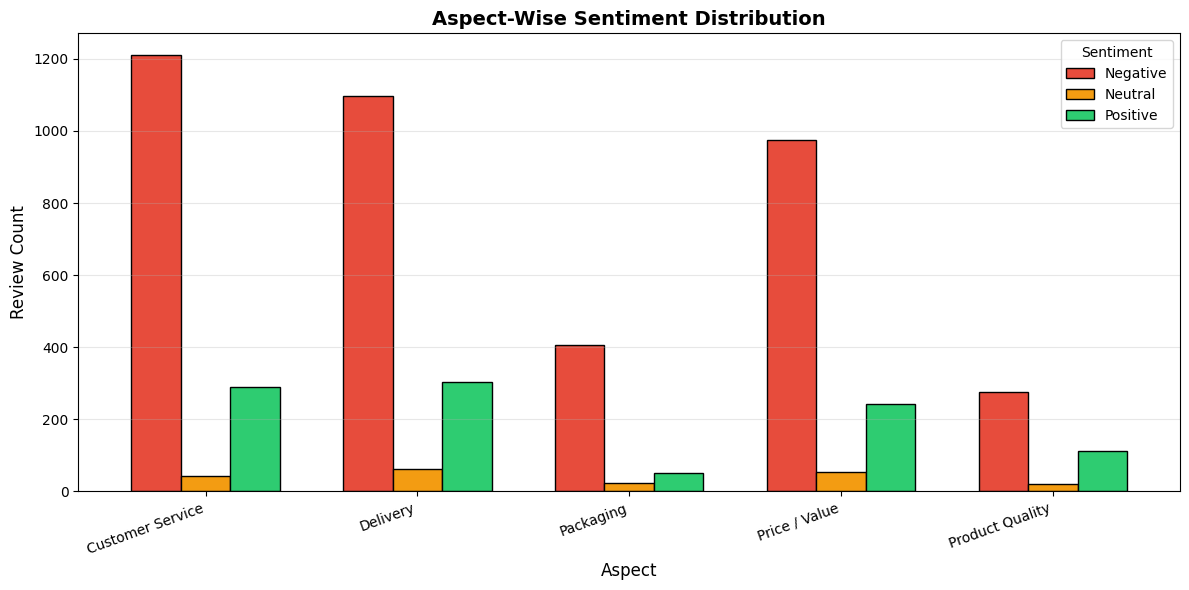

In [ ]:
# ── Grouped bar chart: aspect-wise sentiment ──
ax = aspect_sentiment.plot(
    kind='bar',
    figsize=(12, 6),
    color=['#e74c3c', '#f39c12', '#2ecc71'],
    edgecolor='black',
    width=0.7
)
plt.title('Aspect-Wise Sentiment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Aspect', fontsize=12)
plt.ylabel('Review Count', fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.legend(title='Sentiment')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('absa_aspect_sentiment_bar.png', dpi=150)
plt.show()

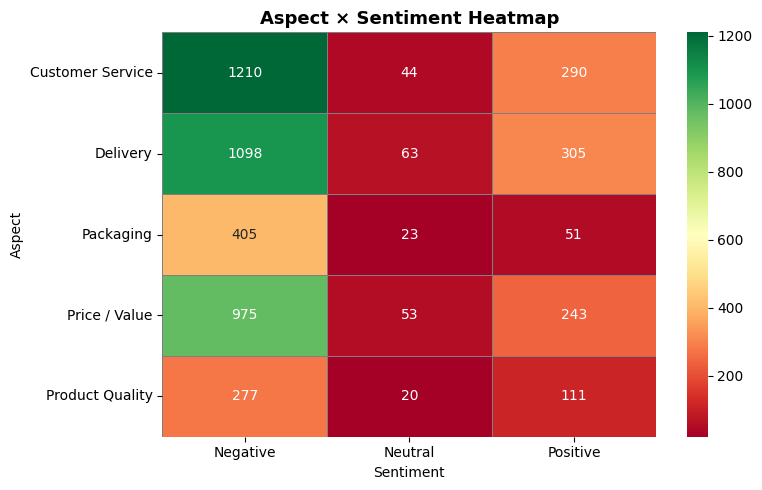

In [ ]:
# ── Heatmap ──
plt.figure(figsize=(8, 5))
sns.heatmap(aspect_sentiment, annot=True, fmt='d', cmap='RdYlGn',
            linewidths=0.5, linecolor='gray')
plt.title('Aspect × Sentiment Heatmap', fontsize=13, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Aspect')
plt.tight_layout()
plt.savefig('absa_aspect_heatmap.png', dpi=150)
plt.show()

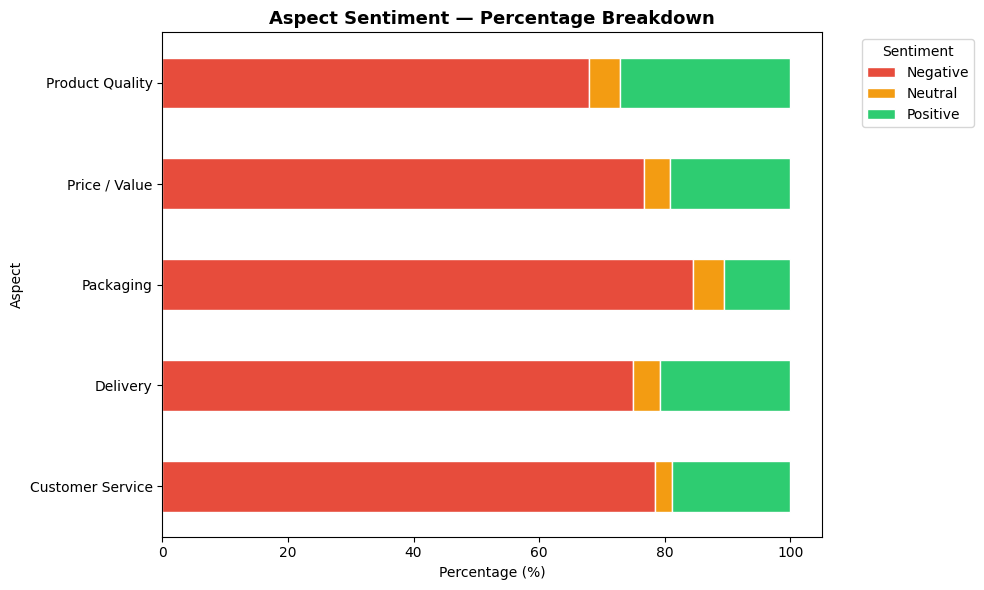

In [ ]:
# ── Stacked percentage bar chart ──
aspect_pct = aspect_sentiment.div(aspect_sentiment.sum(axis=1), axis=0) * 100

ax = aspect_pct.plot(
    kind='barh',
    stacked=True,
    figsize=(10, 6),
    color=['#e74c3c', '#f39c12', '#2ecc71'],
    edgecolor='white'
)
plt.title('Aspect Sentiment — Percentage Breakdown', fontsize=13, fontweight='bold')
plt.xlabel('Percentage (%)')
plt.ylabel('Aspect')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('absa_aspect_pct.png', dpi=150)
plt.show()

## 6. Aspect-Specific Word Clouds

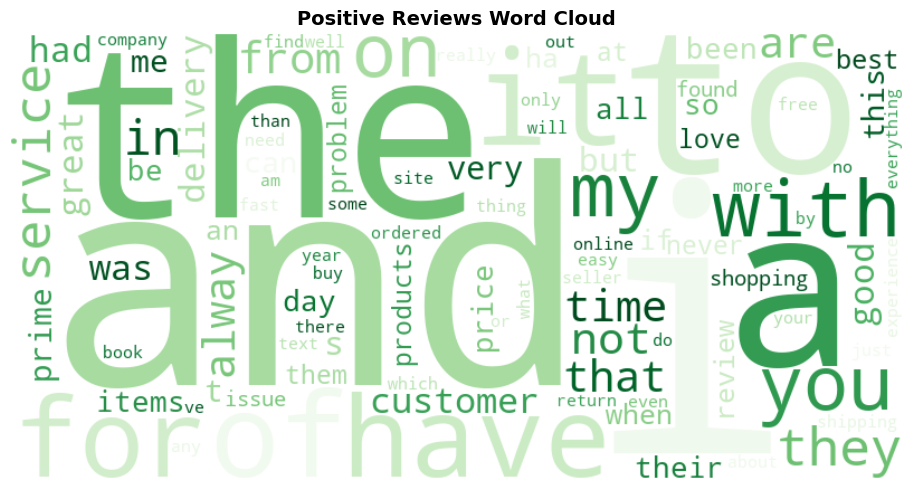

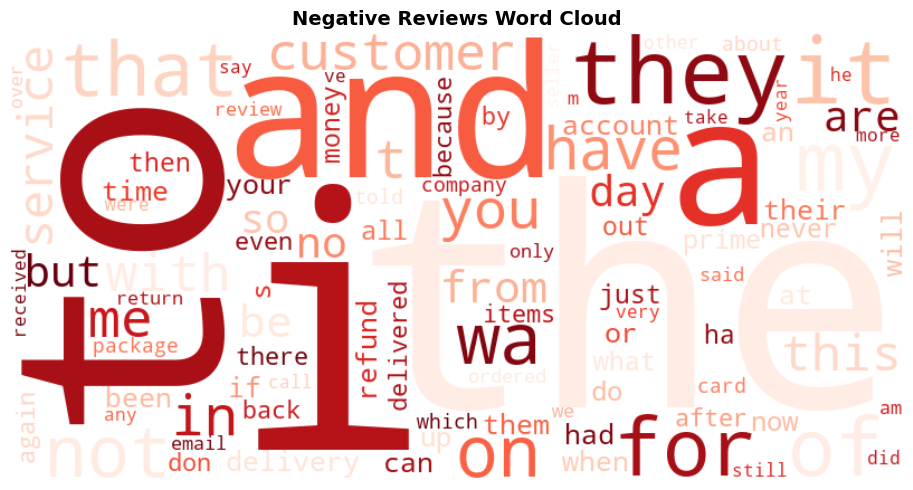

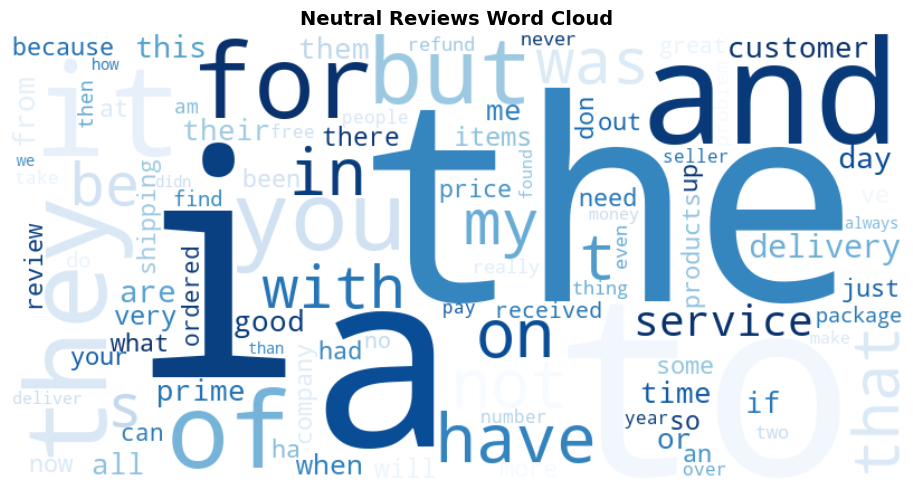

In [ ]:
STOPWORDS_EXTRA = {'amazon', 'product', 'item', 'order', 'one', 'get',
                   'got', 'use', 'used', 'would', 'could', 'also', 'like'}

def make_wordcloud(texts, title, color):
    combined = ' '.join(str(t) for t in texts).lower()
    combined = re.sub(r'http\S+|[^a-z\s]', ' ', combined)
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=color,
        stopwords=STOPWORDS_EXTRA,
        max_words=100,
        collocations=False
    ).generate(combined)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    fname = title.replace(' ', '_').lower() + '_wordcloud.png'
    plt.savefig(fname, dpi=150)
    plt.show()

# Word clouds per sentiment
for sentiment, cmap in [('Positive', 'Greens'), ('Negative', 'Reds'), ('Neutral', 'Blues')]:
    subset = df_absa[df_absa['Sentiment'] == sentiment]['Review Text']
    make_wordcloud(subset, f'{sentiment} Reviews Word Cloud', cmap)

## 7. Zero-Shot ABSA with HuggingFace Pipeline
Use a pre-trained NLI model for zero-shot aspect classification — no fine-tuning needed.

Device set to use cuda:0


                                              review  \
0  i am a prime customer which means i get all my...   
1  In my area there is a lot of flat blocks and w...   
2                              Review text not found   
3  In data 03/08/2022 mi viene accettato il reso ...   
4  Who would choose to sell on Amazon, what a rip...   
5  This is the way I received the bike. As you ca...   
6  Rude, confrontational with there reply and not...   
7  While there are advantages in shipping and pri...   
8  Search on all Amazon platforms .com .nl whatev...   
9  I joined Prime and ordered 2 seperate products...   

                     top_aspect     score  
0         good customer service  0.995703  
1         poor customer service  0.996074  
2  negative delivery experience  0.976888  
3  negative delivery experience  0.928772  
4                    overpriced  0.989665  
5         poor customer service  0.997621  
6         poor customer service  0.994154  
7         poor customer service

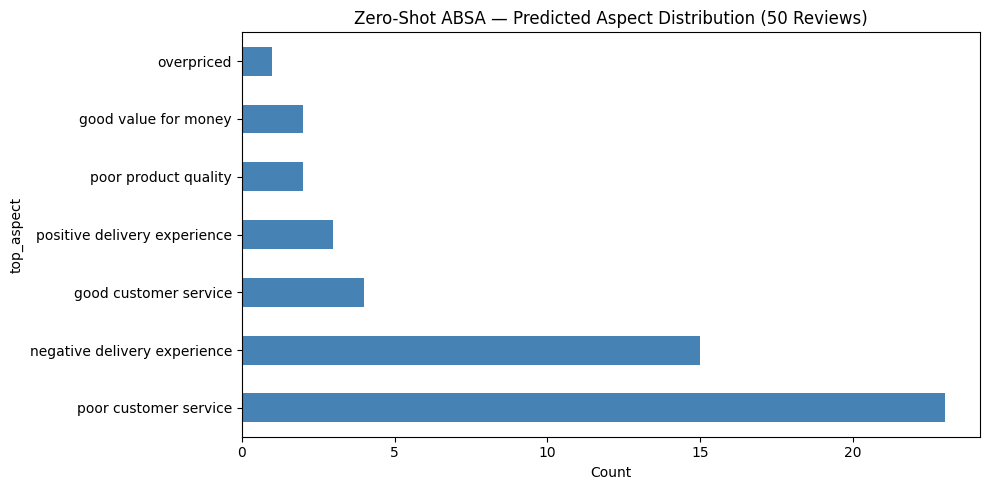

In [ ]:
# Uses facebook/bart-large-mnli for zero-shot classification
zero_shot = pipeline('zero-shot-classification',
                      model='facebook/bart-large-mnli',
                      device=0 if torch.cuda.is_available() else -1)

ABSA_LABELS = ['positive delivery experience', 'negative delivery experience',
               'good product quality', 'poor product quality',
               'good value for money', 'overpriced',
               'good customer service', 'poor customer service']

# Run on small sample
sample_reviews = df_absa['Review Text'].sample(100, random_state=42).tolist()
zs_results = []

for review in sample_reviews[:50]:  # 50 for speed
    res = zero_shot(str(review)[:512], ABSA_LABELS, multi_label=True)
    top_label = res['labels'][0]
    top_score = res['scores'][0]
    zs_results.append({'review': review[:100], 'top_aspect': top_label, 'score': top_score})

zs_df = pd.DataFrame(zs_results)
print(zs_df.head(10))

# Visualize zero-shot aspect distribution
zs_df['top_aspect'].value_counts().plot(kind='barh', figsize=(10, 5), color='steelblue')
plt.title('Zero-Shot ABSA — Predicted Aspect Distribution (50 Reviews)')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('zeroshot_absa_distribution.png', dpi=150)
plt.show()

## 8. Opinion Trend Analysis by Date

C:\Users\Abirami Muthiah\AppData\Local\Temp\ipykernel_20648\1740684280.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_dated['Month'] = df_dated['Parsed_Date'].dt.to_period('M').astype(str)


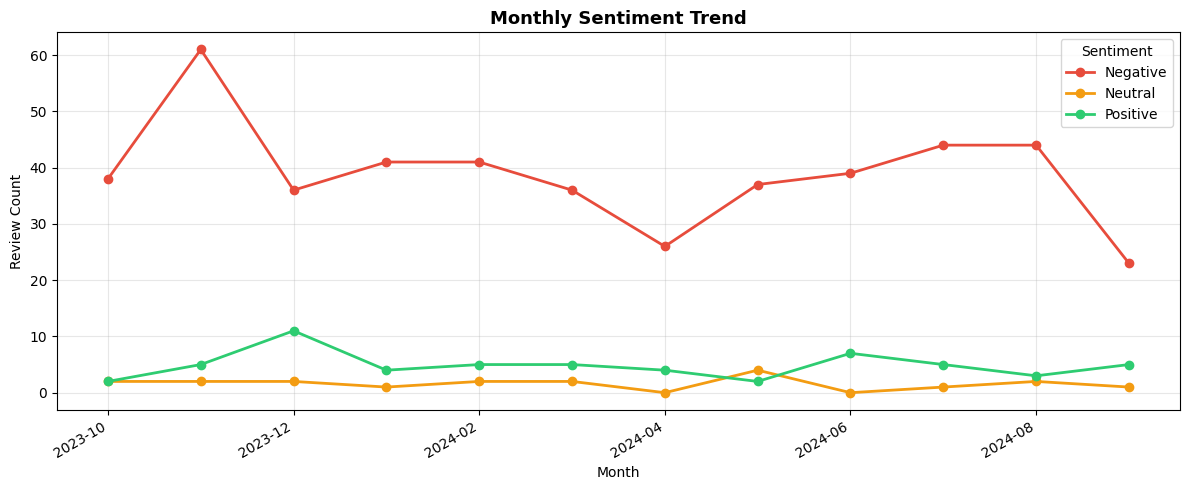

In [ ]:
# Parse dates
df_absa['Parsed_Date'] = pd.to_datetime(df_absa['Review Date'], errors='coerce')
df_dated = df_absa.dropna(subset=['Parsed_Date']).copy()
df_dated['Month'] = df_dated['Parsed_Date'].dt.to_period('M').astype(str)

# Monthly sentiment counts
monthly = df_dated.groupby(['Month', 'Sentiment']).size().unstack(fill_value=0)
for col in ['Negative', 'Neutral', 'Positive']:
    if col not in monthly.columns:
        monthly[col] = 0
monthly = monthly[['Negative', 'Neutral', 'Positive']].tail(12)  # last 12 months

monthly.plot(kind='line', figsize=(12, 5),
             color=['#e74c3c', '#f39c12', '#2ecc71'],
             marker='o', linewidth=2)
plt.title('Monthly Sentiment Trend', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Review Count')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Sentiment')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_sentiment_trend.png', dpi=150)
plt.show()

## 9. Save All ABSA Outputs

In [ ]:
# Save aspect-sentiment matrix
aspect_sentiment.to_csv('absa_aspect_sentiment_matrix.csv')
aspect_pct.to_csv('absa_aspect_sentiment_pct.csv')
zs_df.to_csv('absa_zeroshot_results.csv', index=False)
print('Saved:')
print('  absa_aspect_sentiment_matrix.csv')
print('  absa_aspect_sentiment_pct.csv')
print('  absa_zeroshot_results.csv')
print('  All PNG chart files')

Saved:
  absa_aspect_sentiment_matrix.csv
  absa_aspect_sentiment_pct.csv
  absa_zeroshot_results.csv
  All PNG chart files
